In [1]:
import numpy as np 
import pandas as pd
from sklearn.naive_bayes import  GaussianNB
from sklearn.metrics import f1_score,accuracy_score,classification_report
from sklearn.model_selection import  train_test_split
from sklearn.datasets import  load_iris

In [2]:
data=load_iris()

In [5]:
x=data.data
y=data.target

In [9]:

df = pd.DataFrame(x, columns=data.feature_names)
df['species'] = pd.Categorical.from_codes(data.target, data.target_names)
print("Preview of the dataset:")
print(df.head(), "\n")

Preview of the dataset:
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2   setosa
1                4.9               3.0  ...               0.2   setosa
2                4.7               3.2  ...               0.2   setosa
3                4.6               3.1  ...               0.2   setosa
4                5.0               3.6  ...               0.2   setosa

[5 rows x 5 columns] 



In [10]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [12]:
model=GaussianNB()

In [13]:
model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 97.78%



In [18]:
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [20]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)
predicted_species = data.target_names[prediction[0]]

print(f"Prediction for new flower {new_flower[0]}: {predicted_species}")

Prediction for new flower [5.1, 3.5, 1.4, 0.2]: setosa


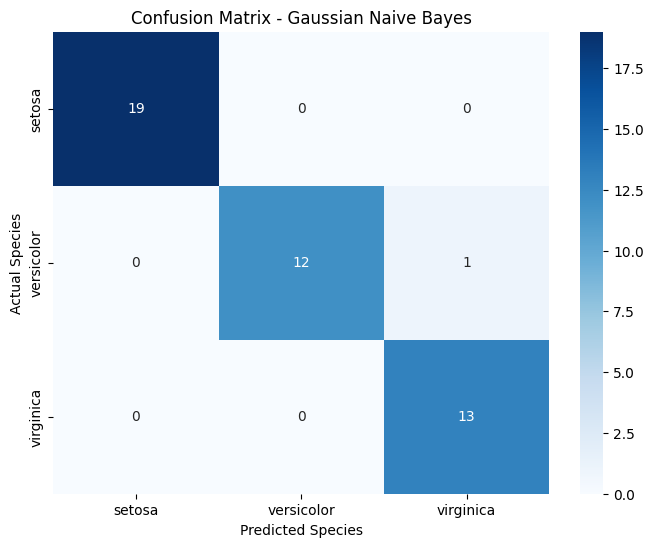

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)

plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()

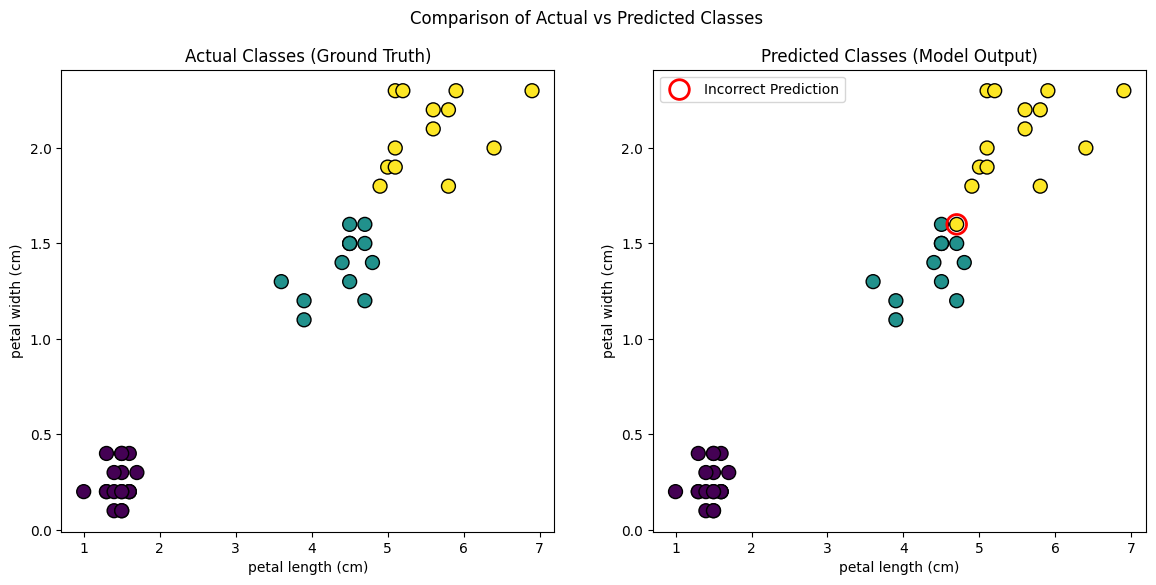

In [ ]:
feature_x_idx, feature_y_idx = 2, 3

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_actual = axes[0].scatter(X_test[:, feature_x_idx], X_test[:, feature_y_idx], 
                                 c=y_test, cmap='viridis', edgecolor='k', s=100)
axes[0].set_title('Actual Classes (Ground Truth)')
axes[0].set_xlabel(data.feature_names[feature_x_idx])
axes[0].set_ylabel(data.feature_names[feature_y_idx])

scatter_pred = axes[1].scatter(X_test[:, feature_x_idx], X_test[:, feature_y_idx], 
                               c=y_pred, cmap='viridis', edgecolor='k', s=100)
axes[1].set_title('Predicted Classes (Model Output)')
axes[1].set_xlabel(data.feature_names[feature_x_idx])
axes[1].set_ylabel(data.feature_names[feature_y_idx])


incorrect_mask = (y_test != y_pred)
axes[1].scatter(X_test[incorrect_mask, feature_x_idx], X_test[incorrect_mask, feature_y_idx], 
                facecolors='none', edgecolors='r', s=200, linewidth=2, label='Incorrect Prediction')

axes[1].legend()
plt.suptitle('Comparison of Actual vs Predicted Classes')
plt.show()